# 3단계: 전이학습 (Transfer Learning) — 개미 vs 벌 분류

ImageNet(1,400만 장)으로 사전학습된 **ResNet18**을 가져와, **단 244장**의 사진으로 개미/벌 분류기를 만듭니다.

**이 실습의 핵심 메시지**: 데이터가 이렇게 적으면 밑바닥부터 학습은 불가능합니다.
하지만 전이학습으로는 90% 이상의 정확도가 나옵니다.

**실습 흐름**

1. **특징 추출**: 사전학습 층은 전부 동결하고 마지막 분류층만 학습
2. **파인튜닝**: 뒤쪽 층(layer4)까지 풀어서 낮은 학습률로 추가 학습

추가 학습 포인트: `ImageFolder` — 폴더 구조로 데이터셋을 만드는 방법.
나중에 **직접 찍은 사진**으로 분류기를 만들 때 그대로 쓰는 방식입니다.

> 데이터셋 47MB는 PyTorch 공식 서버에서 받으므로 몇 초면 끝납니다.
> 전체 실행 시간: RTX 2060 기준 약 3~5분

## 0. 설정 + 데이터 다운로드

In [10]:
import os
import time
import urllib.request
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

BATCH_SIZE = 32

# PyTorch 공식 서버에서 데이터셋 다운로드 (47MB)
URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
if not os.path.exists("data/hymenoptera_data"):
    os.makedirs("data", exist_ok=True)
    print("다운로드 중...")
    urllib.request.urlretrieve(URL, "data/hymenoptera_data.zip")
    with zipfile.ZipFile("data/hymenoptera_data.zip") as z:
        z.extractall("data")
    os.remove("data/hymenoptera_data.zip")
    print("완료!")
else:
    print("데이터셋이 이미 있습니다.")

사용 장치: cuda
데이터셋이 이미 있습니다.


## 1. 데이터 준비 — ImageFolder

이 데이터셋은 아래 폴더 구조로 되어 있습니다:

```
hymenoptera_data/
├── train/
│   ├── ants/   (개미 사진 124장)
│   └── bees/   (벌 사진 121장)
└── val/
    ├── ants/   (70장)
    └── bees/   (83장)
```

`ImageFolder`는 이런 구조를 읽어 **폴더 이름을 클래스 라벨로** 자동 인식합니다.
직접 모은 사진도 이렇게 폴더에 나눠 담기만 하면 데이터셋이 됩니다.

**전이학습의 핵심 규칙**: 입력을 사전학습 때와 같은 형식(224×224, ImageNet 평균/표준편차)으로 맞춥니다.
학습 데이터에는 **데이터 증강**(무작위 자르기/뒤집기)을 추가해 적은 데이터를 뻥튀기하는 효과를 냅니다.

In [11]:
# 학습용: 데이터 증강 포함 (매 에폭 다른 변형 -> 과적합 방지)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),        # 무작위 위치/크기로 자르고 224로
    transforms.RandomHorizontalFlip(),        # 50% 확률로 좌우 반전
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet 평균
                         std=[0.229, 0.224, 0.225]),   # ImageNet 표준편차
])

# 검증용: 증강 없이 크기만 맞춤
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder("data/hymenoptera_data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/hymenoptera_data/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

classes = train_dataset.classes   # 폴더 이름에서 자동 추출
print(f"클래스: {classes}")
print(f"학습: {len(train_dataset)}장, 검증: {len(val_dataset)}장")

클래스: ['ants', 'bees']
학습: 244장, 검증: 153장


### 데이터 확인

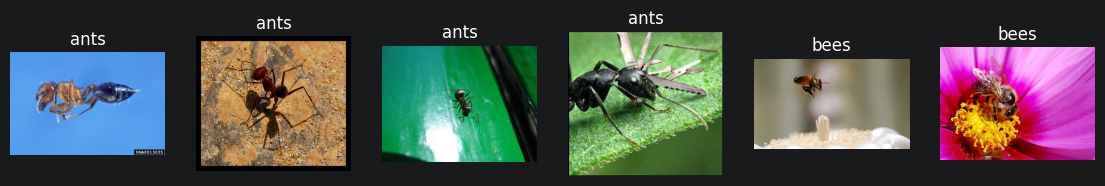

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for i, ax in enumerate(axes):
    path, label = train_dataset.samples[i * 40]   # 띄엄띄엄 샘플링
    ax.imshow(Image.open(path))
    ax.set_title(classes[label])
    ax.axis("off")
plt.show()

## 2. 사전학습 모델 불러오기 + 수정

전이학습의 핵심 3단계:

1. **사전학습 가중치와 함께 모델 로드** (`weights=...`)
2. **기존 층 동결** — `requires_grad = False` 로 역전파에서 제외
3. **마지막 분류층 교체** — ImageNet 1,000개 클래스 → 우리 문제 2개 클래스

In [13]:
# 1) ImageNet 사전학습 가중치로 ResNet18 로드 (첫 실행 시 45MB 다운로드)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2) 모든 파라미터 동결 (학습에서 제외)
for param in model.parameters():
    param.requires_grad = False

# 3) 마지막 분류층(fc)을 새 것으로 교체
#    새로 만든 층은 requires_grad=True가 기본이므로 이 층만 학습된다
print(f"교체 전 fc: {model.fc}")
model.fc = nn.Linear(model.fc.in_features, len(classes))   # 1000 -> 2 클래스
print(f"교체 후 fc: {model.fc}")

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터: {total:,}개 중 학습 대상: {trainable:,}개 ({100*trainable/total:.3f}%)")

교체 전 fc: Linear(in_features=512, out_features=1000, bias=True)
교체 후 fc: Linear(in_features=512, out_features=2, bias=True)
전체 파라미터: 11,177,538개 중 학습 대상: 1,026개 (0.009%)


전체의 **0.01%만 학습**한다는 점에 주목하세요. 나머지는 ImageNet에서 배운 지식을 그대로 사용합니다.

## 3. 학습/평가 함수

2단계와 완전히 같은 구조(핵심 4줄 패턴)입니다.

In [14]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, optimizer, epoch):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()              # 1) 기울기 초기화
        outputs = model(images)            #    순전파
        loss = criterion(outputs, labels)  # 2) 손실 계산
        loss.backward()                    # 3) 역전파
        optimizer.step()                   # 4) 파라미터 업데이트

        total_loss += loss.item()
    print(f"  Epoch {epoch} 평균 loss: {total_loss / len(train_loader):.4f}")


def evaluate(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            predicted = model(images).argmax(dim=1)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / len(val_dataset)
    print(f"  -> 검증 정확도: {acc:.2f}%")
    return acc

## 4. 1차 학습: 특징 추출 (분류층만 학습)

244장밖에 없지만 사전학습된 특징 덕분에 몇 에폭 만에 높은 정확도가 나옵니다.

In [7]:
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=0.001)

start = time.perf_counter()
for epoch in range(1, 4):   # 3 에폭
    train_one_epoch(model, optimizer, epoch)
    acc_frozen = evaluate(model)
print(f"소요 시간: {time.perf_counter() - start:.0f}초")

  Epoch 1 평균 loss: 0.7778
  -> 검증 정확도: 58.17%
  Epoch 2 평균 loss: 0.5518
  -> 검증 정확도: 79.74%
  Epoch 3 평균 loss: 0.4282
  -> 검증 정확도: 88.89%
소요 시간: 10초


**생각해볼 점**: 학습 이미지 244장은 밑바닥부터 CNN을 학습하기엔 터무니없이 적습니다
(2단계 MNIST는 60,000장이었죠). 그런데도 90% 안팎이 나오는 것이 전이학습의 힘입니다.

## 5. 2차 학습: 파인튜닝 (layer4까지 해제)

ResNet의 마지막 블록(layer4)도 학습에 참여시킵니다.

**핵심**: 사전학습된 지식을 망가뜨리지 않도록 **학습률을 10분의 1로** 낮춥니다.

In [8]:
# layer4 동결 해제
for param in model.layer4.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 대상 파라미터: {trainable:,}개로 증가")

# 낮은 학습률로 새 옵티마이저 구성
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=0.0001)

start = time.perf_counter()
for epoch in range(4, 7):   # 3 에폭 추가
    train_one_epoch(model, optimizer, epoch)
    acc_finetuned = evaluate(model)
print(f"소요 시간: {time.perf_counter() - start:.0f}초")

print(f"\n특징 추출만: {acc_frozen:.2f}%  ->  파인튜닝 후: {acc_finetuned:.2f}%")

학습 대상 파라미터: 8,394,754개로 증가
  Epoch 4 평균 loss: 0.2981
  -> 검증 정확도: 94.12%
  Epoch 5 평균 loss: 0.1807
  -> 검증 정확도: 92.81%
  Epoch 6 평균 loss: 0.1144
  -> 검증 정확도: 94.77%
소요 시간: 8초

특징 추출만: 88.89%  ->  파인튜닝 후: 94.77%


## 6. 예측 결과 확인 + 모델 저장

빨간 제목 = 틀린 예측입니다. 어떤 사진에서 틀리는지 관찰해보세요.

/tmp/ipykernel_662/3771135438.py:13: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_662/3771135438.py:13: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_662/3771135438.py:13: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_662/3771135438.py:13: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/

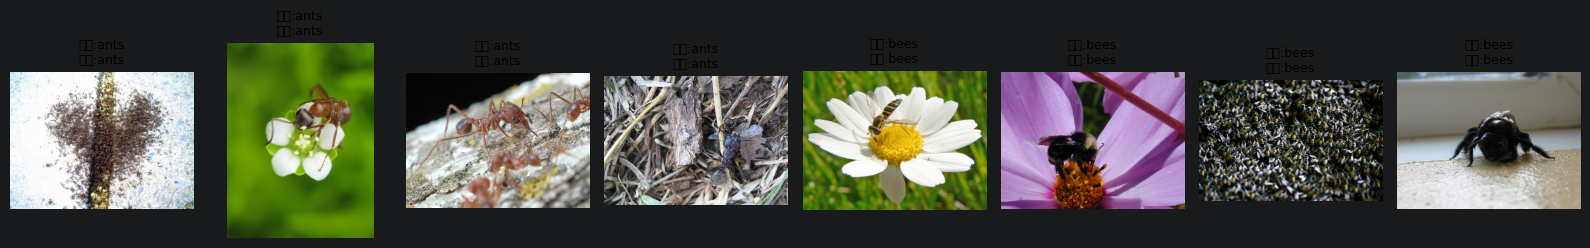

모델 저장 완료: resnet18_ants_bees.pt


In [9]:
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
model.eval()
with torch.no_grad():
    for i, ax in enumerate(axes):
        idx = i * 19                                   # 검증셋에서 띄엄띄엄
        image, label = val_dataset[idx]                # 변환된 텐서 (모델 입력용)
        path, _ = val_dataset.samples[idx]             # 원본 이미지 (표시용)
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
        ax.imshow(Image.open(path))
        color = "black" if pred == label else "red"
        ax.set_title(f"정답:{classes[label]}\n예측:{classes[pred]}", color=color, fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "resnet18_ants_bees.pt")
print("모델 저장 완료: resnet18_ants_bees.pt")

---
**3단계 완료!**

**배운 것 정리**

- 사전학습 모델 로드 → 동결 → 분류층 교체가 전이학습의 기본 패턴
- 적은 데이터(244장)로도 전이학습이면 높은 정확도 가능
- `ImageFolder`: 폴더 구조만으로 나만의 데이터셋 구성
- 데이터 증강으로 적은 데이터 보완
- 파인튜닝 시 낮은 학습률이 필수인 이유

**도전 과제**

1. **나만의 분류기**: 관심 있는 두 가지 대상(예: 강아지 품종 2종)의 사진을 클래스당 50장씩 모아
   같은 폴더 구조로 넣고 이 노트북을 그대로 돌려보세요. 이게 실전 전이학습입니다.
2. 파인튜닝 학습률을 0.01로 올리면 어떻게 되는지 실험해보세요 (사전학습 지식 파괴 체험)
3. `models.resnet34`로 바꾸면 정확도가 오를까요?

다음 4단계에서는 같은 원리를 텍스트(Hugging Face 모델 파인튜닝)에 적용합니다.